Name: Christopher A. Lee\
Date: 04/14/2026\
Prof: Dr. Azarnoosh\
Course: Machine Learning for Data Analysis - ENBC 321

In [1]:
# Libraries
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import silhouette_score

import numpy as np

In [2]:
# Import Data
df = pd.read_csv('patients_data.csv')

# Preprocess Data
X = df.copy()

# Standardization
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

In [3]:
# Principal Component Analysis Dimension Reduction, Manual Derviation
# Compute covariance matrix
cov_mat = np.cov(X_scaled, rowvar=False)
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
# Sort eigenvalues and eigenvalues in descending order
sorted_index = np.argsort(eigenvalues)[::-1]
sorted_eigenvectors = eigenvectors[:, sorted_index]
# Select 2 highest principal components based on eigenvectors and original dataset
eigenvector_subset = sorted_eigenvectors[:, 0:2]
X_pca = np.dot(X_scaled, eigenvector_subset)
# Retrieve top two principal components and caclulate the captured variance
top_eigenvalues = eigenvalues[sorted_index[:2]]
total_variance = np.sum(eigenvalues)
explained_variance = np.sum(top_eigenvalues)
variance_ratio = (explained_variance / total_variance) * 100

print("Corresponding Eigenvalues:")
print(eigenvalues)
print("\nTop Two Principal Component Eigenvalues:")
print(top_eigenvalues)
print("\nTotal Variance Captured From Top Two Principal Components:")
print(variance_ratio)

Corresponding Eigenvalues:
[0.08018861 0.15347523 0.27483582 0.58729394 3.94622321]

Top Two Principal Component Eigenvalues:
[3.94622321 0.58729394]

Total Variance Captured From Top Two Principal Components:
89.91475687158228


Text(0, 0.5, 'Principal Component 2')

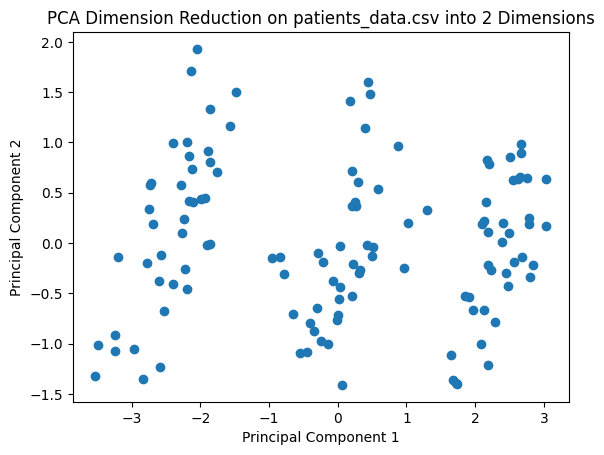

In [4]:
# Plot of 2D data after PCA transformation
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("PCA Dimension Reduction on patients_data.csv into 2 Dimensions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

Text(0, 0.5, 'Principal Component 2')

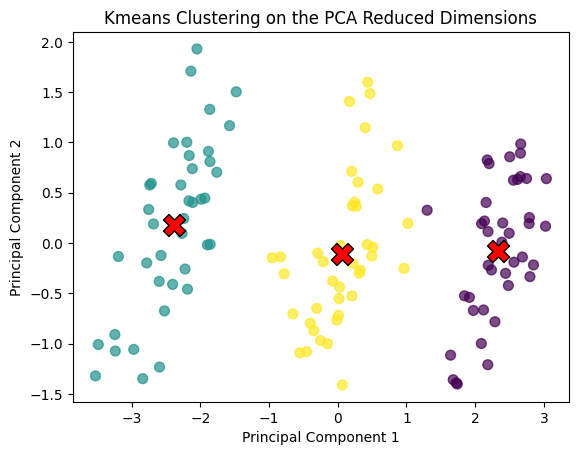

In [5]:
# K Means Models
model_km = KMeans(n_clusters=3, init='k-means++', random_state=321).fit(X_pca)
clf = NearestCentroid().fit(X_pca, model_km.labels_)

# Reduced Clustered 2D plots
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=model_km.labels_, cmap='viridis', s=50, alpha=0.7)
plt.scatter(clf.centroids_[:, 0], clf.centroids_[:, 1], c='red', marker='X', s=250, label='Cluster Centers', edgecolors='black')
plt.title("Kmeans Clustering on the PCA Reduced Dimensions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")